# Getting Started with the Simple API

The `metaheuristic_designer.simple` module provides ready‑to‑use wrappers for
common metaheuristics.  You just pass your objective function, a few
hyperparameters, and a random seed – the wrapper builds the whole strategy
and returns an `Algorithm` instance.

In [1]:
import metaheuristic_designer as mhd
from metaheuristic_designer.benchmarks import Sphere
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Reproducibility
rng = mhd.check_rng(42)

In [2]:
n_iterations = 100

## 1. Objective function (Sphere in 5D, minimisation)

In [3]:
DIM = 5
objfunc = Sphere(DIM, mode="min")

## 2. Run a Genetic Algorithm

The GA wrapper chooses sensible defaults: tournament selection, Gaussian
mutation, uniform crossover, elitism, etc.  You only need to set the
population size and maybe the number of generations.

In [4]:
ga_algo = mhd.simple.genetic_algorithm_real(
    objfunc,
    population_size=100,
    mutation_strength=0.1,
    mutated_components=1,
    stop_condition_str="max_iterations",
    max_iterations=n_iterations,
    reporter="tqdm",
    rng=rng,
)
ga_population = ga_algo.optimize()

  0%|          |   0% [00:00<?, ?it/s]

## 3. Run a Differential Evolution algorithm

DE works directly on real vectors.  The wrapper selects the `DE/rand/1`
variant by default.

In [5]:
de_algo = mhd.simple.differential_evolution_real(
    objfunc,
    population_size=100,
    de_operator_name="DE/current-to-rand/1",
    F=0.8,
    Cr=0.9,
    stop_condition_str="max_iterations",
    max_iterations=n_iterations,
    reporter="tqdm",
    rng=rng,
)
de_algo.reporter.verbose_timer = -1
de_population = de_algo.optimize()

  0%|          |   0% [00:00<?, ?it/s]

## 4. Run a Particle Swarm Optimisation (PSO)

PSO uses a swarm of particles with velocity updates.  The simple wrapper
handles the required `PSOEncoding`, `ExtendedInitializer` and
`ExtendedConstraintHandler` internally.

In [6]:
pso_algo = mhd.simple.particle_swarm_real(
    objfunc,
    population_size=50,
    w=0.7,
    c1=1.5,
    c2=1.5,
    stop_condition_str="max_iterations",
    max_iterations=n_iterations,
    reporter="tqdm",
    rng=rng,
)
pso_population = pso_algo.optimize()

  0%|          |   0% [00:00<?, ?it/s]

## 5. Compare the results

In [7]:
_, ga_best = ga_population.best_solution()
_, de_best = de_population.best_solution()
_, pso_best = pso_population.best_solution()

print(f"GA best objective:  {ga_best:.6g}")
print(f"DE best objective:  {de_best:.6g}")
print(f"PSO best objective: {pso_best:.6g}")

GA best objective:  603.123
DE best objective:  0.00681696
PSO best objective: 4.53713e-08


## 6. Three‑way convergence plot

We extract the history of each algorithm and plot the best objective over
generations on the same axes.

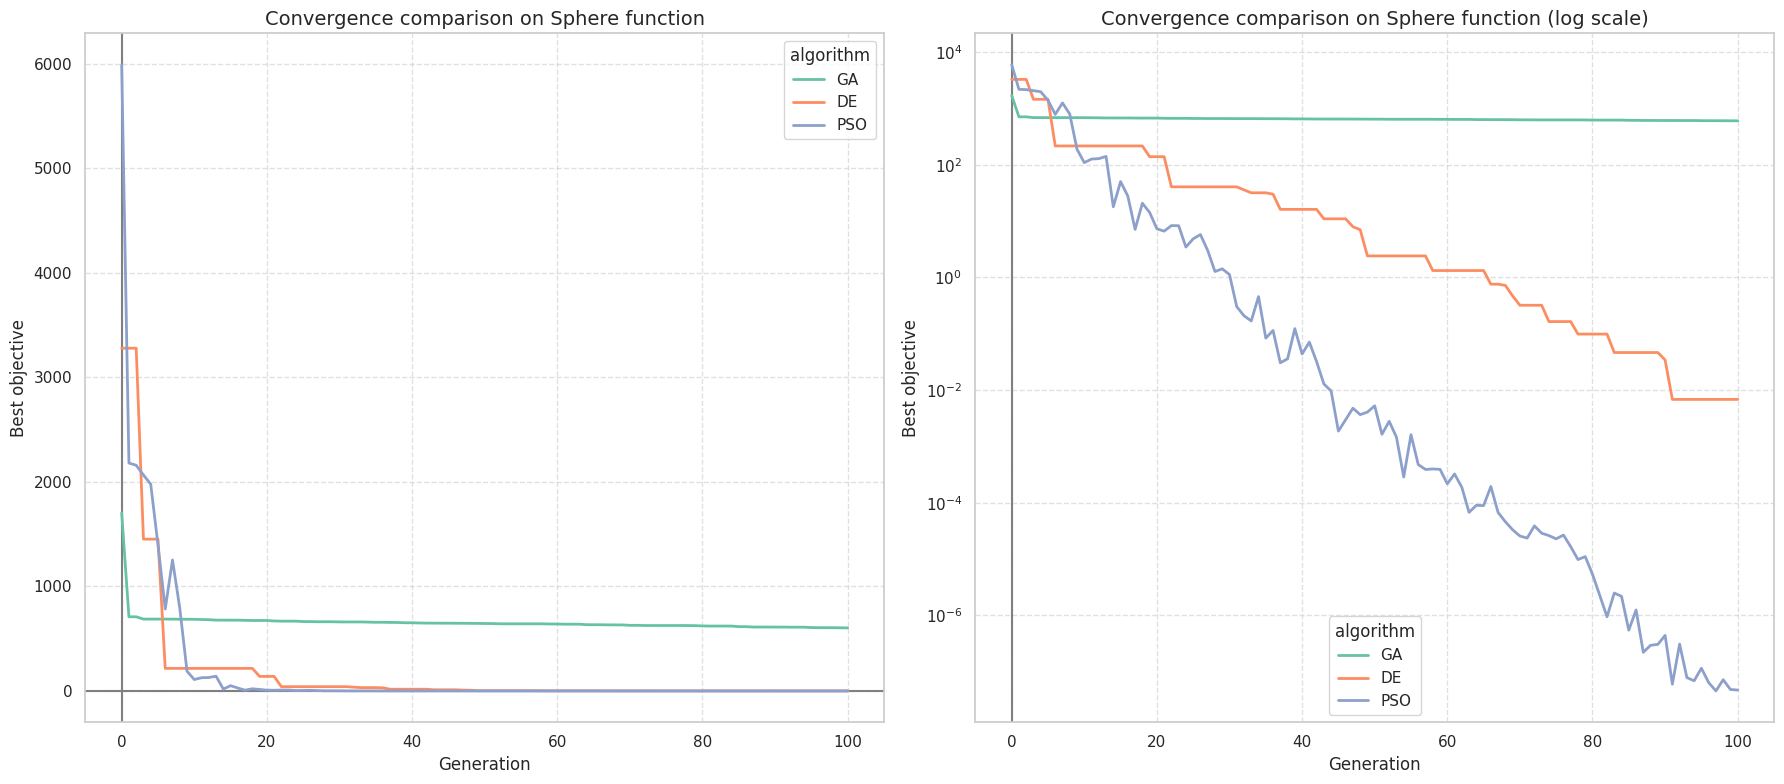

In [8]:
# Retrieve dataframes
ga_df = ga_algo.history_tracker.to_pandas()
de_df = de_algo.history_tracker.to_pandas()
pso_df = pso_algo.history_tracker.to_pandas()

# Add an 'algorithm' column for seaborn hue
ga_df["algorithm"] = "GA"
de_df["algorithm"] = "DE"
pso_df["algorithm"] = "PSO"

combined = pd.concat([ga_df, de_df, pso_df], ignore_index=True)

# Plot
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Normal scale plot
sns.lineplot(data=combined, x="iteration", y="best_objective", hue="algorithm", linewidth=2, palette="Set2", ax=ax1, zorder=10)
ax1.set_xlabel("Generation", fontsize=12)
ax1.set_ylabel("Best objective", fontsize=12)
ax1.set_title("Convergence comparison on Sphere function", fontsize=14)
ax1.grid(linestyle="--", alpha=0.6, zorder=-12)
ax1.axhline(0, color="grey")
ax1.axvline(0, color="grey")

# Log scale plot
sns.lineplot(data=combined, x="iteration", y="best_objective", hue="algorithm", linewidth=2, palette="Set2", ax=ax2, zorder=10)
ax2.set_xlabel("Generation", fontsize=12)
ax2.set_ylabel("Best objective", fontsize=12)
ax2.set_title("Convergence comparison on Sphere function (log scale)", fontsize=14)
ax2.set_yscale("log")  # Sphere spans orders of magnitude
ax2.grid(linestyle="--", alpha=0.6)
ax2.axhline(0, color="grey")
ax2.axvline(0, color="grey")

plt.tight_layout()
plt.show()

## 7. Other simple wrappers

All follow the same pattern:

- **`hill_climb_real` / `local_search_real`** – for fast local optimisation.
- **`simulated_annealing_real`** – good for escaping local minima.
- **`random_search_real`** – baseline.

For binary or integer problems, use the `_binary`, `_discrete` or
`_permutation` variants.  All accept a `rng` for reproducibility.